In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

In [2]:
pd.options.display.float_format = '{:.2f}'.format


In [3]:
unames = ['user_id', 'gender', 'age', 'occupation', 'zip']
user_df = pd.read_table(
    'ml-1m/users.dat',
    sep='::',
    header=None,
    names=unames,
    engine='python'
)

In [4]:
mnames = ['movie_id', 'title', 'genres']
movies_df = pd.read_table(
    'ml-1m/movies.dat',
    sep='::',
    header=None,
    names=mnames,
    engine='python',
    encoding='latin-1'
)

In [5]:
rnames = ['user_id', 'movie_id', 'rating', 'timestamp']
ratings_df = pd.read_table(
    'ml-1m/ratings.dat',
    sep='::',
    header=None,
    names=rnames,
    engine='python'
)

In [6]:
ratings_df

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [7]:
movies_df

,movie_id,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy
...,...,...,...
3878,3948,Meet the Parents (2000),Comedy
3879,3949,Requiem for a Dream (2000),Drama
3880,3950,Tigerland (2000),Drama
3881,3951,Two Family House (2000),Drama


In [8]:
ratings_df

,user_id,movie_id,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291
...,...,...,...,...
1000204,6040,1091,1,956716541
1000205,6040,1094,5,956704887
1000206,6040,562,5,956704746
1000207,6040,1096,4,956715648


In [9]:
df = pd.merge(pd.merge(ratings_df, user_df), movies_df, sort=True)
df

,user_id,movie_id,rating,timestamp,gender,age,occupation,zip,title,genres
0,1,1,5,978824268,F,1,10,48067,Toy Story (1995),Animation|Children's|Comedy
1,6,1,4,978237008,F,50,9,55117,Toy Story (1995),Animation|Children's|Comedy
2,8,1,4,978233496,M,25,12,11413,Toy Story (1995),Animation|Children's|Comedy
3,9,1,5,978225952,M,25,17,61614,Toy Story (1995),Animation|Children's|Comedy
4,10,1,5,978226474,F,35,1,95370,Toy Story (1995),Animation|Children's|Comedy
...,...,...,...,...,...,...,...,...,...,...
1000204,5812,3952,4,992072099,F,25,7,92120,"Contender, The (2000)",Drama|Thriller
1000205,5831,3952,3,986223125,M,25,1,92120,"Contender, The (2000)",Drama|Thriller
1000206,5837,3952,4,1011902656,M,25,7,60607,"Contender, The (2000)",Drama|Thriller
1000207,5927,3952,1,979852537,M,35,14,10003,"Contender, The (2000)",Drama|Thriller


### EDA

#### 3.1 Visão geral do dataset
- Shape, tipos de dados, valores ausentes, duplicatas. Estatísticas descritivas dos ratings.

In [10]:
df.shape

(1000209, 10)

In [11]:
df.isnull().sum()

user_id       0
movie_id      0
rating        0
timestamp     0
gender        0
age           0
occupation    0
zip           0
title         0
genres        0
dtype: int64

### 3.2 Distribuição das avaliações

In [12]:
ratings_por_usuario = df.groupby("user_id").size()
ratings_por_usuario

user_id
1        53
2       129
3        51
4        21
5       198
       ... 
6036    888
6037    202
6038     20
6039    123
6040    341
Length: 6040, dtype: int64

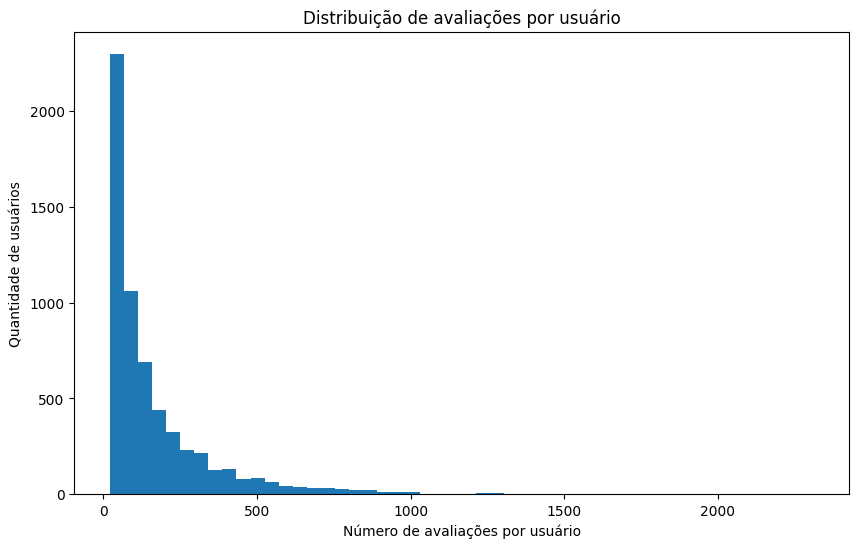

In [13]:
plt.figure(figsize=(10, 6))
plt.hist(ratings_por_usuario, bins=50)
plt.xlabel("Número de avaliações por usuário")
plt.ylabel("Quantidade de usuários")
plt.title("Distribuição de avaliações por usuário")
plt.show()

Observa-se uma forte concentração de usuários com baixo nível de atividade, enquanto uma pequena parcela apresenta um número elevado de avaliações. A maior parte dos usuários avaliou poucos filmes, ao passo que poucos usuários contribuíram com centenas ou até milhares de avaliações.

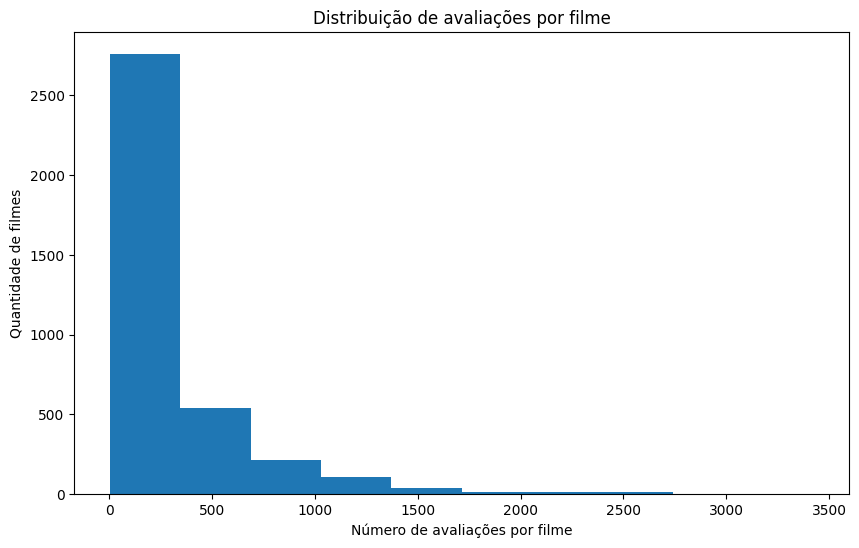

In [14]:
ratings_por_filme = df.groupby("movie_id").size()

plt.figure(figsize=(10, 6))
plt.hist(ratings_por_filme)
plt.xlabel("Número de avaliações por filme")
plt.ylabel("Quantidade de filmes")
plt.title("Distribuição de avaliações por filme")
plt.show()

Ao analisar a distribuição de avaliações por filme, observa-se uma forte concentração de filmes com baixo número de avaliações, enquanto poucos filmes acumulam um volume muito elevado de interações. A maioria dos filmes recebeu poucas avaliações, ao passo que uma pequena parcela concentra centenas ou até milhares.

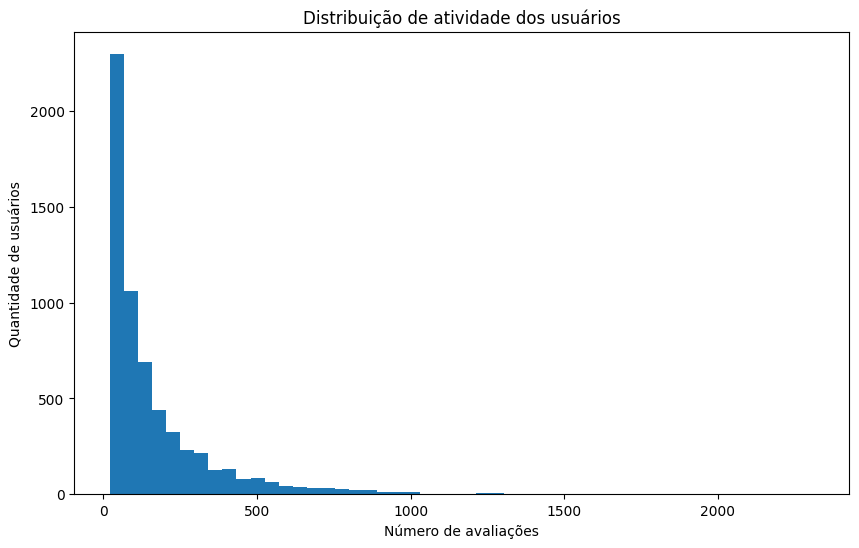

In [15]:
ratings_por_usuario = (
    df.groupby("user_id")
    .size()
    .reset_index(name="num_itens_avaliados")
)

plt.figure(figsize=(10, 6))
plt.hist(ratings_por_usuario["num_itens_avaliados"], bins=50)
plt.xlabel("Número de avaliações")
plt.ylabel("Quantidade de usuários")
plt.title("Distribuição de atividade dos usuários")
plt.show()

### 3.3 Filmes mais avaliados

In [16]:
top_avaliados = (
    df.groupby(["movie_id", "title"])
    .size()
    .reset_index(name="num_ratings")
    .sort_values("num_ratings", ascending=False)
)

top_avaliados.head(20)

,movie_id,title,num_ratings
2651,2858,American Beauty (1999),3428
253,260,Star Wars: Episode IV - A New Hope (1977),2991
1106,1196,Star Wars: Episode V - The Empire Strikes Back...,2990
1120,1210,Star Wars: Episode VI - Return of the Jedi (1983),2883
466,480,Jurassic Park (1993),2672
1848,2028,Saving Private Ryan (1998),2653
575,589,Terminator 2: Judgment Day (1991),2649
2374,2571,"Matrix, The (1999)",2590
1178,1270,Back to the Future (1985),2583
579,593,"Silence of the Lambs, The (1991)",2578


In [17]:
top20 = top_avaliados.head(20).sort_values("num_ratings",ascending=False)

In [18]:
media_filmes = (
    df.groupby(["movie_id", "title"])
    .agg(
        media_rating=("rating", "mean"),
        num_ratings=("rating", "count")
    )
    .reset_index()
)

media_filmes_filtrado = media_filmes[media_filmes["num_ratings"] >= 50]

top_media = media_filmes_filtrado.sort_values("media_rating", ascending=False).head(20)

top_media.head(20)

,movie_id,title,media_rating,num_ratings
2698,2905,Sanjuro (1962),4.61,69
1839,2019,Seven Samurai (The Magnificent Seven) (Shichin...,4.56,628
309,318,"Shawshank Redemption, The (1994)",4.55,2227
802,858,"Godfather, The (1972)",4.52,2223
708,745,"Close Shave, A (1995)",4.52,657
49,50,"Usual Suspects, The (1995)",4.52,1783
513,527,Schindler's List (1993),4.51,2304
1066,1148,"Wrong Trousers, The (1993)",4.51,882
861,922,Sunset Blvd. (a.k.a. Sunset Boulevard) (1950),4.49,470
1108,1198,Raiders of the Lost Ark (1981),4.48,2514


####  Filmes mais bem avaliado
- Para isso foi considerado rating >=4 como um filme bem avaliado, 3 foi considerado uma avaliação neutra. Então foi feito um novo atributo feedback aonde 3 é 1 (avaliação neutra), acima 2 (avaliação positiva) e abaixo 0 

In [19]:
df["feedback"] = df["rating"].apply(lambda x: 2 if x >= 4 else (1 if x == 3 else 0))

In [20]:
top_bem_avaliados = (
    df[df["feedback"] == 2]  
    .groupby(["movie_id", "title"])
    .size()
    .reset_index(name="num_likes")
    .sort_values("num_likes", ascending=False)
)

top_bem_avaliados.head(20)

,movie_id,title,num_likes
2526,2858,American Beauty (1999),2853
245,260,Star Wars: Episode IV - A New Hope (1977),2622
1041,1196,Star Wars: Episode V - The Empire Strikes Back...,2510
1754,2028,Saving Private Ryan (1998),2260
1043,1198,Raiders of the Lost Ark (1981),2260
563,593,"Silence of the Lambs, The (1991)",2252
2260,2571,"Matrix, The (1999)",2171
2434,2762,"Sixth Sense, The (1999)",2163
1055,1210,Star Wars: Episode VI - Return of the Jedi (1983),2127
575,608,Fargo (1996),2074


In [21]:
top20_ids = set(top20["title"])
top_media_ids = set(top_bem_avaliados.head(20)["title"])
intersec = top20_ids.intersection(top_media_ids)
intersec

{'American Beauty (1999)',
 'Back to the Future (1985)',
 'Braveheart (1995)',
 'Fargo (1996)',
 'L.A. Confidential (1997)',
 'Matrix, The (1999)',
 'Princess Bride, The (1987)',
 'Raiders of the Lost Ark (1981)',
 'Saving Private Ryan (1998)',
 "Schindler's List (1993)",
 'Shakespeare in Love (1998)',
 'Silence of the Lambs, The (1991)',
 'Sixth Sense, The (1999)',
 'Star Wars: Episode IV - A New Hope (1977)',
 'Star Wars: Episode V - The Empire Strikes Back (1980)',
 'Star Wars: Episode VI - Return of the Jedi (1983)',
 'Terminator 2: Judgment Day (1991)'}

In [22]:
top20_ids = set(top20["title"])
top_media_ids = set(top_media.head(20)["title"])
intersec = top20_ids.intersection(top_media_ids)
intersec

{'Raiders of the Lost Ark (1981)',
 "Schindler's List (1993)",
 'Star Wars: Episode IV - A New Hope (1977)'}

Ao comparar os filmes mais avaliados com os mais bem avaliados, observa-se uma forte sobreposição entre os dois conjuntos: dos 20 filmes com maior número de avaliações positivas, 17 também estão entre os mais avaliados no geral.

Esse resultado indica uma relação entre popularidade e volume de avaliações positivas. Filmes mais populares tendem a acumular mais avaliações e, consequentemente, também concentram um maior número absoluto de avaliações positivas.

No entanto, isso não implica necessariamente que esses filmes sejam os melhores avaliados em termos de média. Quando comparamos com a média de avaliações, observamos um baixo valor na intersecção, com somente 3 filmes. Então parece refletir muito mais  um efeito de escala: quanto maior o número de avaliações, maior a probabilidade de acumular avaliações positivas em termos absolutos.

#### 3.4 Perfil dos usuários

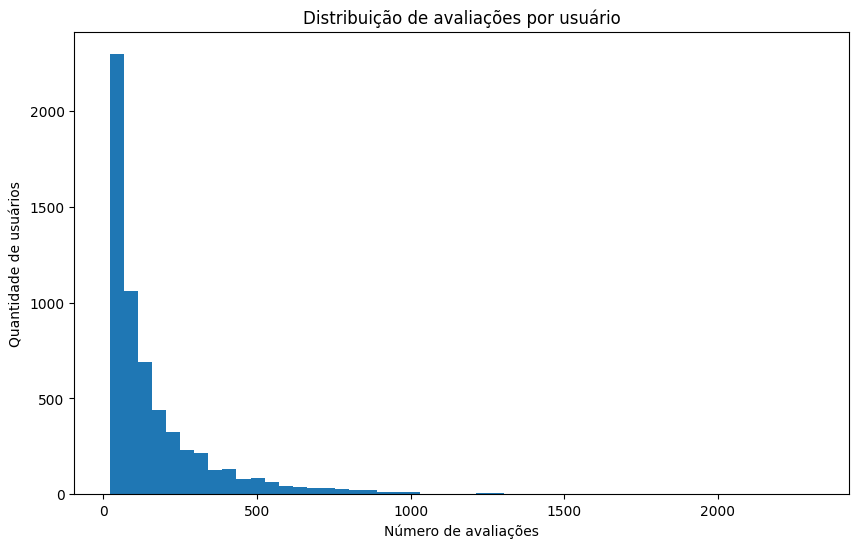

In [23]:
plt.figure(figsize=(10, 6))
plt.hist(ratings_por_usuario["num_itens_avaliados"], bins=50)
plt.xlabel("Número de avaliações")
plt.ylabel("Quantidade de usuários")
plt.title("Distribuição de avaliações por usuário")
plt.show()

In [24]:
q1 = ratings_por_usuario["num_itens_avaliados"].quantile(0.25)
q3 = ratings_por_usuario["num_itens_avaliados"].quantile(0.75)

usuarios_esporadicos = ratings_por_usuario[
    ratings_por_usuario["num_itens_avaliados"] <= q1
]

usuarios_ativos = ratings_por_usuario[
    ratings_por_usuario["num_itens_avaliados"] >= q3
]

len(usuarios_esporadicos), len(usuarios_ativos)

(1522, 1511)

A utilização de quartis permite definir limites baseados na própria distribuição dos dados, evitando escolhas arbitrárias. Dessa forma, usuários nos extremos da distribuição (abaixo de Q1 e acima de Q3) podem ser identificados como esporádicos e ativos, respectivamente.

In [25]:
ratings_por_usuario

,user_id,num_itens_avaliados
0,1,53
1,2,129
2,3,51
3,4,21
4,5,198
...,...,...
6035,6036,888
6036,6037,202
6037,6038,20
6038,6039,123


In [26]:
ratings_por_usuario["num_itens_avaliados"].quantile([0.25, 0.5, 0.75])

0.25    44.00
0.50    96.00
0.75   208.00
Name: num_itens_avaliados, dtype: float64

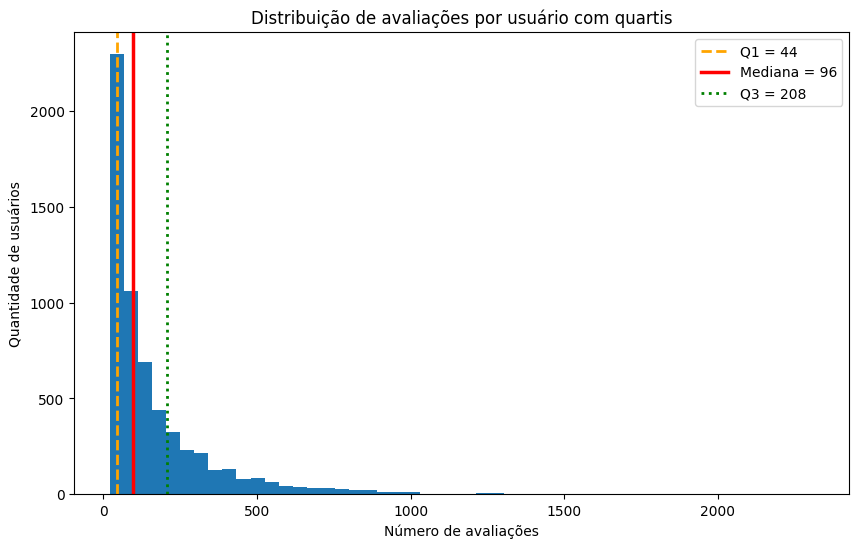

In [27]:
q1 = ratings_por_usuario["num_itens_avaliados"].quantile(0.25)
q2 = ratings_por_usuario["num_itens_avaliados"].quantile(0.5)
q3 = ratings_por_usuario["num_itens_avaliados"].quantile(0.75)

plt.figure(figsize=(10, 6))
plt.hist(ratings_por_usuario["num_itens_avaliados"], bins=50)

plt.axvline(q1, color='orange', linestyle='--', linewidth=2, label=f'Q1 = {q1:.0f}')
plt.axvline(q2, color='red', linestyle='-', linewidth=2.5, label=f'Mediana = {q2:.0f}')
plt.axvline(q3, color='green', linestyle=':', linewidth=2, label=f'Q3 = {q3:.0f}')

plt.xlabel("Número de avaliações")
plt.ylabel("Quantidade de usuários")
plt.title("Distribuição de avaliações por usuário com quartis")
plt.legend()

plt.show()

Os quartis da distribuição indicam que 25% dos usuários avaliaram até 44 filmes, enquanto a mediana é de 96 avaliações. Já os 25% mais ativos avaliaram mais de 208 filmes. Essa diferença entre os quartis evidencia uma distribuição assimétrica, com poucos usuários altamente ativos e muitos usuários com baixa participação

### 3.5 - Análise por gênero


In [28]:
df["genres"] = df["genres"].str.split("|")
df_genres = df.explode("genres")

In [29]:
generos_populares = (
    df_genres.groupby("genres")
    .size()
    .reset_index(name="num_avaliacoes")
    .sort_values("num_avaliacoes", ascending=False)
)

generos_populares.head(20)

,genres,num_avaliacoes
4,Comedy,356580
7,Drama,354529
0,Action,257457
15,Thriller,189680
14,Sci-Fi,157294
13,Romance,147523
1,Adventure,133953
5,Crime,79541
10,Horror,76386
3,Children's,72186


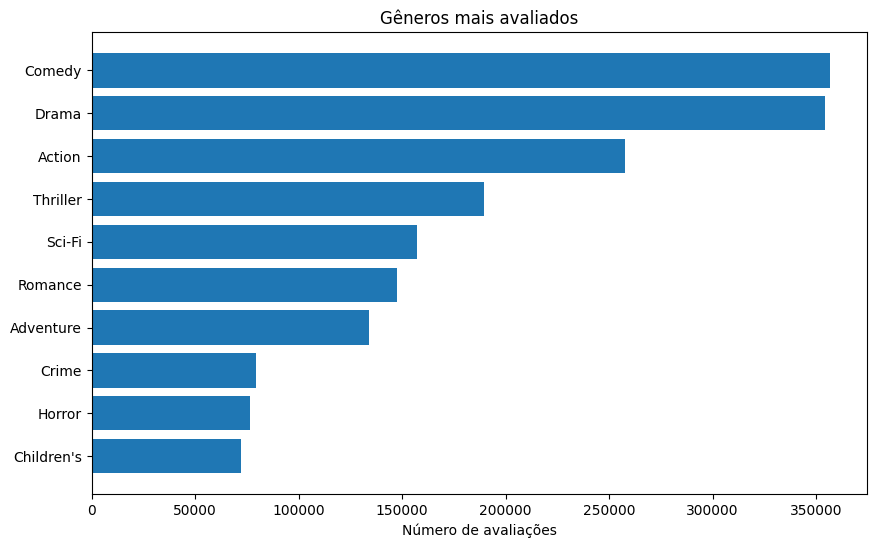

In [30]:
top10 = generos_populares.head(10).sort_values("num_avaliacoes")

plt.figure(figsize=(10, 6))
plt.barh(top10["genres"], top10["num_avaliacoes"])
plt.xlabel("Número de avaliações")
plt.title("Gêneros mais avaliados")
plt.show()

A distribuição de avaliações por gênero mostra que Comedy e Drama são os gêneros com maior número de avaliações, seguidos por Action e Thriller. Isso indica que esses gêneros são os mais populares entre os usuários, concentrando a maior parte das interações.

In [31]:
generos_stats = (
    df_genres.groupby("genres")
    .agg(
        media_rating=("feedback", "mean"),
        num_avaliacoes=("feedback", "count")
    )
    .reset_index()
)

top_generos_rating = generos_stats.sort_values("media_rating", ascending=False)

top_generos_rating.head(30)

,genres,media_rating,num_avaliacoes
9,Film-Noir,1.70,18261
6,Documentary,1.63,7910
16,War,1.59,68527
7,Drama,1.53,354529
5,Crime,1.49,79541
2,Animation,1.48,43293
11,Musical,1.46,41533
12,Mystery,1.46,40178
17,Western,1.45,20683
13,Romance,1.43,147523


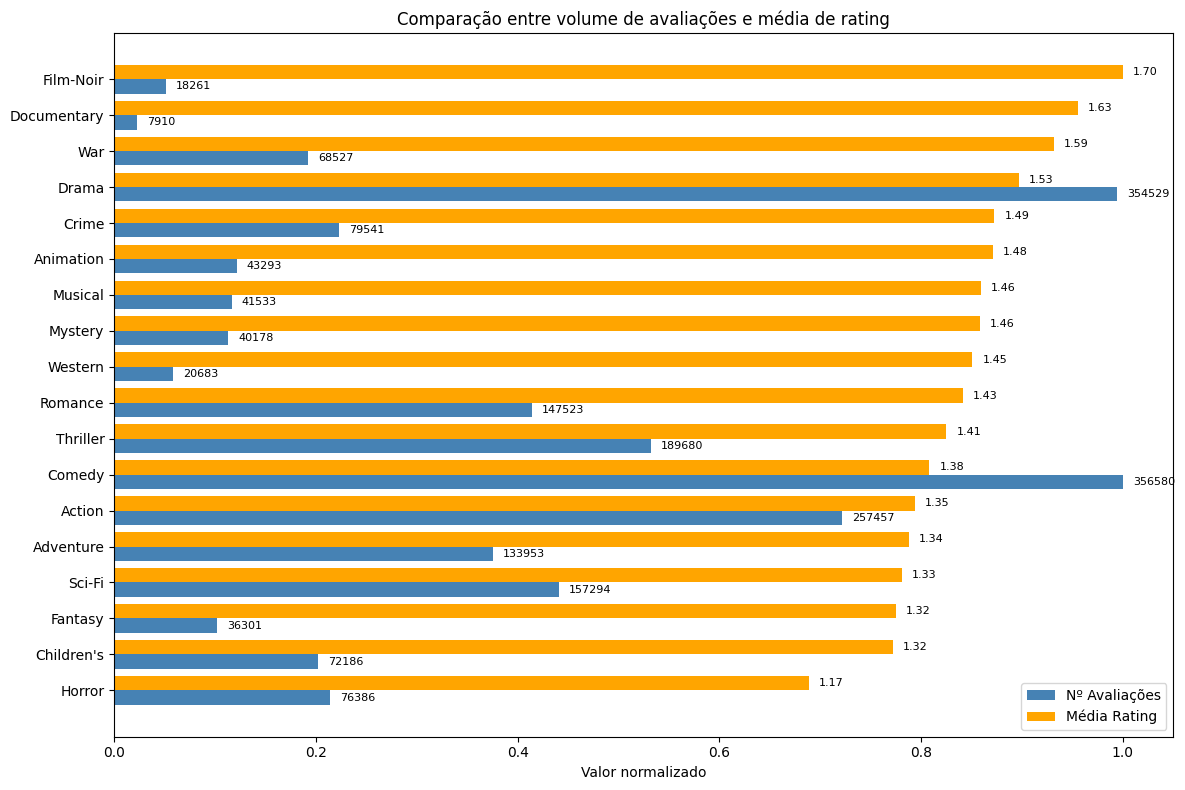

In [32]:
top10 = (
    top_generos_rating
    .sort_values("media_rating", ascending=False)
    .sort_values("media_rating")
)

num_norm = top10["num_avaliacoes"] / top10["num_avaliacoes"].max()
rating_norm = top10["media_rating"] / top10["media_rating"].max()

y = np.arange(len(top10))
height = 0.4

plt.figure(figsize=(12, 8))

bars1 = plt.barh(y - height/2, num_norm, height, label="Nº Avaliações", color="steelblue")
bars2 = plt.barh(y + height/2, rating_norm, height, label="Média Rating", color="orange")

plt.yticks(y, top10["genres"])
plt.xlabel("Valor normalizado")
plt.title("Comparação entre volume de avaliações e média de rating")

for i, bar in enumerate(bars1):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{int(top10["num_avaliacoes"].iloc[i])}',
             va='center', fontsize=8)

for i, bar in enumerate(bars2):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'{top10["media_rating"].iloc[i]:.2f}',
             va='center', fontsize=8)

plt.legend()
plt.tight_layout()
plt.show()

A análise das médias de avaliação por gênero revela que os gêneros com melhor avaliação não são necessariamente os mais populares. Gêneros como Film-Noir e Documentary apresentam as maiores médias de nota, porém com um número relativamente baixo de avaliações. Por outro lado, gêneros como Drama e Comédia, além de também apresentam boas médias, se destacam por terem sido bem avaliados, e com um alto numero de avaliações

### 3.6 - Esparsidade da matriz


In [33]:
df

,user_id,movie_id,rating,timestamp,gender,age,occupation,zip,title,genres,feedback
0,1,1,5,978824268,F,1,10,48067,Toy Story (1995),"[Animation, Children's, Comedy]",2
1,6,1,4,978237008,F,50,9,55117,Toy Story (1995),"[Animation, Children's, Comedy]",2
2,8,1,4,978233496,M,25,12,11413,Toy Story (1995),"[Animation, Children's, Comedy]",2
3,9,1,5,978225952,M,25,17,61614,Toy Story (1995),"[Animation, Children's, Comedy]",2
4,10,1,5,978226474,F,35,1,95370,Toy Story (1995),"[Animation, Children's, Comedy]",2
...,...,...,...,...,...,...,...,...,...,...,...
1000204,5812,3952,4,992072099,F,25,7,92120,"Contender, The (2000)","[Drama, Thriller]",2
1000205,5831,3952,3,986223125,M,25,1,92120,"Contender, The (2000)","[Drama, Thriller]",1
1000206,5837,3952,4,1011902656,M,25,7,60607,"Contender, The (2000)","[Drama, Thriller]",2
1000207,5927,3952,1,979852537,M,35,14,10003,"Contender, The (2000)","[Drama, Thriller]",0


In [34]:
num_usuarios = df["user_id"].nunique()
num_filmes = df["movie_id"].nunique()
num_avaliacoes = len(df)

esparsidade = 1 - (num_avaliacoes / (num_usuarios * num_filmes))
esparsidade

0.9553163743776871

A matriz usuário × filme apresenta alta esparsidade, indicando que a grande maioria das possíveis interações entre usuários e filmes não está presente no conjunto de dados. Isso ocorre porque cada usuário avalia apenas uma pequena fração dos filmes disponíveis.

### 4.1 Transformação para formato transacional


In [35]:
df_pos = df[df["feedback"] == 2] ## filtrar somente feedbacks positivos

In [36]:
df_filtered = df_pos.groupby("movie_id").filter(lambda x: len(x) >= 20)
df_filtered = df_filtered.groupby("user_id").filter(lambda x: len(x) >= 10)

In [37]:
transacoes = (
    df_filtered.groupby("user_id")["title"]
    .apply(list)
) ## Lista de itemsets

In [38]:
transacoes

user_id
1       [Toy Story (1995), Pocahontas (1995), Apollo 1...
2       [Braveheart (1995), Desperado (1995), Like Wat...
3       [Happy Gilmore (1996), Star Wars: Episode IV -...
4       [Star Wars: Episode IV - A New Hope (1977), Ju...
5       [City of Lost Children, The (1995), Twelve Mon...
                              ...                        
6036    [Sense and Sensibility (1995), Leaving Las Veg...
6037    [Sense and Sensibility (1995), Seven (Se7en) (...
6038    [Eat Drink Man Woman (1994), Forrest Gump (199...
6039    [Taxi Driver (1976), Umbrellas of Cherbourg, T...
6040    [City of Lost Children, The (1995), Twelve Mon...
Name: title, Length: 5946, dtype: object

### 4.2 Escolha e justificativa do algoritmo

In [39]:
te = TransactionEncoder()

te_array = te.fit(transacoes).transform(transacoes)

df_encoded = pd.DataFrame(te_array, columns=te.columns_)

In [40]:
frequent_itemsets = fpgrowth(
    df_encoded,
    min_support = 0.04,
    use_colnames=True
)

O algoritmo FP-Growth foi escolhido por sua eficiência em bases esparsas e de alta dimensionalidade, como a matriz usuário×filme observada na EDA. Diferente do Apriori, ele evita a geração explícita de combinações de itens, reduzindo significativamente o custo computacional.

### 4.3 Definição de hiperparâmetros
Devido à alta esparsidade da matriz usuário×filme, seria desejável um suporte baixo, porém valores inferiores a 4% tornaram o FP-Growth inviável computacionalmente; assim, adotou-se min_support = 0.04. Foi utilizada confiança mínima de 0.5 para garantir que o consequente ocorra com frequência relevante dado o antecedente; valores menores (como 0.3) geraram excesso de regras e inviabilizaram o processamento. Além disso, aplicou-se filtro de lift > 1 para manter apenas associações acima do esperado ao acaso.


In [41]:
frequent_itemsets

,support,itemsets
0,0.44,frozenset({Star Wars: Episode IV - A New Hope ...
1,0.38,frozenset({Saving Private Ryan (1998)})
2,0.36,"frozenset({Sixth Sense, The (1999)})"
3,0.35,frozenset({Fargo (1996)})
4,0.35,frozenset({Schindler's List (1993)})
...,...,...
1152000,0.04,"frozenset({Being John Malkovich (1999), Wonder..."
1152001,0.04,"frozenset({American Beauty (1999), Wonder Boys..."
1152002,0.04,"frozenset({Doors, The (1991), American Beauty ..."
1152003,0.05,"frozenset({American Beauty (1999), Bulworth (1..."


### 4.4 Extração e filtragem das regras


In [42]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.5
)

rules = rules[rules["lift"] > 1]

Como existem muitos blockbusters (filmes muito populares que quase todo mundo viu), o Suporte e a Confiança podem ser altos por mera coincidência. O Lift maior que 1 serve para filtrar essas coincidências e garantir que os filmes estão realmente relacionados entre si.

In [43]:
rules = rules.sort_values('lift', ascending=False)

In [44]:
rules.head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
11690821,frozenset({Star Wars: Episode V - The Empire S...,frozenset({Star Wars: Episode IV - A New Hope ...,0.08,0.06,0.05,0.57,9.44,1.00,0.04,2.18,0.97,0.48,0.54,0.67
11690817,frozenset({Star Wars: Episode IV - A New Hope ...,frozenset({Star Wars: Episode V - The Empire S...,0.06,0.08,0.05,0.77,9.44,1.00,0.04,3.92,0.95,0.48,0.74,0.67
11690848,"frozenset({Raiders of the Lost Ark (1981), Wro...",frozenset({Star Wars: Episode IV - A New Hope ...,0.08,0.06,0.04,0.55,9.16,1.00,0.04,2.10,0.96,0.44,0.52,0.62
11690845,frozenset({Star Wars: Episode IV - A New Hope ...,"frozenset({Raiders of the Lost Ark (1981), Wro...",0.06,0.08,0.04,0.69,9.16,1.00,0.04,2.96,0.95,0.44,0.66,0.62
11690846,frozenset({Star Wars: Episode IV - A New Hope ...,"frozenset({Close Shave, A (1995), Raiders of t...",0.08,0.05,0.04,0.50,9.12,1.00,0.04,1.89,0.97,0.43,0.47,0.63
11690847,"frozenset({Close Shave, A (1995), Raiders of t...",frozenset({Star Wars: Episode IV - A New Hope ...,0.05,0.08,0.04,0.75,9.12,1.00,0.04,3.74,0.94,0.43,0.73,0.63
7357783,"frozenset({Aliens (1986), Star Wars: Episode V...","frozenset({Die Hard (1988), Star Wars: Episode...",0.07,0.06,0.04,0.58,9.11,1.00,0.04,2.21,0.96,0.44,0.55,0.61
7357884,"frozenset({Die Hard (1988), Star Wars: Episode...","frozenset({Aliens (1986), Star Wars: Episode V...",0.06,0.07,0.04,0.64,9.11,1.00,0.04,2.61,0.95,0.44,0.62,0.61
11690854,"frozenset({Close Shave, A (1995), Raiders of t...",frozenset({Star Wars: Episode V - The Empire S...,0.05,0.08,0.04,0.74,9.08,1.00,0.04,3.48,0.94,0.42,0.71,0.62
11690819,"frozenset({Close Shave, A (1995), Star Wars: E...",frozenset({Star Wars: Episode IV - A New Hope ...,0.06,0.08,0.05,0.75,9.07,1.00,0.04,3.68,0.95,0.47,0.73,0.65


### 4.5 Interpretação das regras

As regras mais fortes indicam que usuários que avaliam positivamente determinados filmes têm alta probabilidade de também avaliar outros títulos específicos, com associações muito acima do esperado ao acaso (lift ≈ 9).

### Padrão por franquia

Observa-se um padrão dominante de consumo dentro de franquias. Por exemplo, filmes da série *Star Wars* aparecem fortemente associados entre si, com alta confiança e lift. Isso indica que usuários tendem a assistir múltiplos filmes da mesma série, caracterizando um comportamento sequencial.

### Padrão por gênero

Há um agrupamento consistente de filmes de ação e ficção científica, como *Star Wars*, *Alien*, *Aliens* e *Die Hard*. Esse padrão sugere que usuários com interesse em um desses filmes tendem a consumir outros do mesmo estilo, indicando preferência por esse tipo de conteúdo.

### Conexão entre franquias

Além do consumo dentro da mesma franquia, há associações entre diferentes séries do mesmo gênero. Por exemplo, filmes de *Star Wars*, *Alien* e *Die Hard* aparecem frequentemente juntos nas regras, indicando que os usuários transitam entre diferentes franquias com características semelhantes.

### Padrão por época

A maioria dos filmes presentes nas regras pertence às décadas de 1970 e 1980. Isso sugere um padrão de consumo voltado para filmes clássicos, possivelmente influenciado pela relevância cultural e popularidade desses títulos.

### Presença de filmes icônicos

Algumas regras combinam filmes de diferentes gêneros, mas amplamente reconhecidos, como *O Poderoso Chefão*, *Star Wars* e *Indiana Jones*. Isso indica que os usuários tendem a consumir obras consideradas clássicas ou de grande impacto, independentemente do gênero.

In [45]:
supports = [0.1, 0.08, 0.06, 0.05]

results = []

for s in supports:
    frequent_itemsets = fpgrowth(df_encoded, min_support=s, use_colnames=True)

    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.5)

    results.append({
        "support": s,
        "num_rules": len(rules),
        "avg_confidence": rules["confidence"].mean(),
        "avg_lift": rules["lift"].mean()
    })

In [46]:
df_results = pd.DataFrame(results)
print(df_results)

   support  num_rules  avg_confidence  avg_lift
0     0.10      11775            0.67      2.16
1     0.08      59486            0.67      2.37
2     0.06     534785            0.67      2.70
3     0.05    2294177            0.67      2.96


A diminuição do suporte mínimo aumenta drasticamente o número de regras, evidenciando a explosão combinatória. A confiança média permanece estável, enquanto o lift cresce, indicando associações mais específicas, porém com perda de interpretabilidade devido ao volume elevado de regras.